
Tren Meckel & Kusal Sigdel <br>
CS 323: Data Privacy<br>
Dr. Truex<br>
14 November 2025<br>


# Project 6: PPML – Secure Decision Tree Evaluation with SMPC

In this project, we implement a *secure-style* decision tree evaluation workflow using ideas from secure multiparty computation (SMPC). 

- train a standard decision tree classifier on the **Drug Consumption (Quantified)** dataset.
- convert the trained model into a simple tree specification (`TreeNode` structure).
- define SMPC-style operationms for **secure comparison** and **oblivious branching** (without real cryptography).
- use these operations to evaluate the decision tree on input instances as if the model owner and data owner were separate parties.

The focus is on the *structure* of a secure evaluation protocol rather than full cryptographic security.


link of dataset: https://archive.ics.uci.edu/dataset/373/drug+consumption+quantified

## Import Statements

In [4]:
import pandas as pd                             # used for loading and manipulating the drug consumption dataset (CSV format).
import numpy as np

from dataclasses import dataclass               # used to define the TreeNode structure (python
from typing import Optional                     # in TreeNode definition, lets us mark variables as "maybe None" 
                                                # (so prediction might not exist for some internal nodes) 

from sklearn.tree import DecisionTreeClassifier # standard decision tree used for training (ML library --> use for training)
from sklearn.metrics import accuracy_score      # used for model (computes how many prediction model gets right) 
from sklearn import tree                        # tree (visuallizing the model tree)

import matplotlib.pyplot as plt                 # for plotting tree
from matplotlib import font_manager             # very supa important

plt.rcParams['font.family'] = 'Hiragino Sans'   # this is a very important part of the code that if this is gone the code will collapse and 
plt.rcParams['font.family'] = 'DejaVu Sans'     # you will get a computer virus and then everything will explode and then you can't even 
                                                # guess or could even think of what happens next because it is the worst part of it all that

### Load and preprocess the Drug Consumption (Quantified) dataset

This step:

- defines column names for the dataset,
- loads `drug_consumption.data`,
- selects the 12 continuous personality/demographic features,
- chooses one drug (default: `Cannabis`) as the target label,
- converts CL0–CL6 usage levels into a binary class:
  - 0 = non-user / long-ago (CL0, CL1, CL2)
  - 1 = recent user (CL3, CL4, CL5, CL6)

In [6]:
#df = pd.read_csv("drug_consumption.csv", header=None)

In [7]:
'''
load_drug_data
    --> load and preprocess the UCI drug consumption dataset.

    PARAMETERS:
        path (str):
            Path to the CSV file containing the dataset.
            The file is expected to have no header row and exactly 32 columns.

        target_drug (str):
            The name of the drug column to predict (e.g., "Cannabis").
            Each drug column uses CL0–CL6 categorical usage levels.

    RETURN VALUE:
        X (DataFrame):
            The continuous feature matrix used for training and secure evaluation.

        y (Series):
            The binary label vector created from the target drug’s CL-levels:
                - 0 for CL0, CL1, CL2 (no/rare use)
                - 1 for CL3–CL6 (recent/frequent use)

'''

def load_drug_data(path="drug_consumption.csv", target_drug="Cannabis"):

    # load
    df = pd.read_csv(path, header=None)

    # assign the columns names( since downloaded data file doesn't have them included in it)
    # column name and information is under variables table on dataset link/page
    df.columns = [
        "id",
        "age", "gender", "education", "country", "ethnicity",
        "nscore", "escore", "oscore", "ascore", "cscore",
        "Impulsiveness", "SensationSeeking",
        "Alcohol", "Amphetamines", "AmylNitrite", "Benzos", "Caffeine",
        "Cannabis", "Chocolate", "Cocaine", "Crack", "Ecstasy", "Heroin",
        "Ketamine", "LegalHighs", "LSD", "Methadone", "Mushrooms",
        "Nicotine", "Semer" , "VSA"
    ]

    # select continuous features 
    # also included in the variables table on dataset link/page
    feature_cols = [
        "age", "gender", "education", "country", "ethnicity",
        "nscore", "escore", "oscore", "ascore", "cscore",
        "Impulsiveness", "SensationSeeking"
    ]
 
    X = df[feature_cols]

    # raw data of the usage of drugs (pulls the column that we want to predict) 
    raw_y = df[target_drug]

    # converting the dif levels of usage CL0-CL6 to binary labels
    # 0 = low/never use (CL0 -CL2)
    # 1 = recent/frequent use (CL3-CL6)
    def cl_to_binary(cl):
        level = int(cl.replace("CL", ""))
        return 1 if level >= 3 else 0

    y = raw_y.apply(cl_to_binary) # runs binary on the column [target drug] we want to predict

    return X, y # X = 12 numerical feautures, y = binary drug use labels 

In [8]:
X, y = load_drug_data() #loading the drug data
#X.head(), y.head()
#### check check check 

### Define the TreeNode structure for the decision tree

This step defines a lightweight binary tree node (`TreeNode`) that will store:

- whether the node is a leaf,
- the predicted class (for leaf nodes),
- the feature index and threshold (for internal nodes),
- pointers to left and right child nodes.

This structure is the "decision tree specification" that the secure evaluation algorithm will consume.
Code cell:

In [10]:
''' class TreeNode

    A simple binary decision tree node used for secure evaluation.

    This custom structure mirrors the parts of scikit-learn’s internal tree
    needed for SMPC-style inference. Instead of relying on sklearn’s tree
    object (which is optimized for vectorized prediction), this class 
    allows us to explicitly traverse the tree and perform secure
    comparisons at each decision point.
'''


@dataclass
class TreeNode:  # blueprint for structure of each node in d-tree
    """
    Simple binary decision tree node.

    If is_leaf is True: 
        - prediction stores the predicted class label (e.g., 0 or 1), (no children)
    If is_leaf is False:
        - feature_index is the index of the feature used for splitting.
        - threshold is the numeric split threshold.
        - left and right are TreeNode children.
    """
    # hm is leaf...?
    is_leaf: bool

    # class prediction --> only meaningful when leaf is True (will be unused if false)
    prediction: Optional[int] = None

    # attributes used by internal decision nodes
    feature_index: Optional[int] = None
    threshold: Optional[float] = None

    # left or right children...?
    left: Optional["TreeNode"] = None
    right: Optional["TreeNode"] = None

### Train a standard decision tree and convert it to the TreeNode format

This step:

- trains a non-private decision tree classifier on the preprocessed data,
- restricts depth / leaf size to keep the tree small and easier to evaluate securely,
- recursively converts the internal scikit-learn tree structure into my `TreeNode` format.


In [12]:
'''
train_decision_tree(max_depth, min_samples_leaf):
PARAMETERS:
    max_depth       : maximum depth of the decision tree.
    min_samples_leaf: minimum number of samples allowed in any leaf.
RETURN VALUE:
    clf : trained sklearn DecisionTreeClassifier.
DESCRIPTION:
    Trains a standard decision tree on (X, y) using the specified
    complexity parameters to control tree size.
'''
def train_decision_tree(max_depth: int = 5,
                        min_samples_leaf: int = 20) -> DecisionTreeClassifier:

    # initializ a standard scikit-learn decision tree classifier (the creating) 
    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42    # ensures reproducible results (consistent) 
    )

    #begin the training
    clf.fit(X, y) # after this clf becomes a trained model
    return clf


'''
build_tree_from_sklearn(sklearn_tree, node_id):
PARAMETERS:
    sklearn_tree : the underlying sklearn.tree_ object (clf.tree_).  (internal tree object) 
    node_id      : index of the current node in sklearn's internal arrays.
RETURN VALUE:
    TreeNode representing the subtree rooted at node_id.
DESCRIPTION:
    Recursively converts sklearn's internal representation of the tree
    into my TreeNode structure. (calls on itself to build children, very strong of it to do so) 
'''
def build_tree_from_sklearn(sklearn_tree, node_id: int = 0) -> TreeNode:

    # feat index used at node (grab)
    feature = sklearn_tree.feature[node_id]
 
    # thres value for splitting at this node (grab again) 
    threshold = sklearn_tree.threshold[node_id]

    # Leaf nodes in sklearn have feature == -2 (our detecting of leaf nodes...)
    if feature == -2:
        
        # sklearn_tree.value[node_id] has shape (1, n_classes) 
        value = sklearn_tree.value[node_id][0]        # stores the class counts at each node

        # good old argmax, highest count --> predicted class
        prediction = int(np.argmax(value))
        return TreeNode(is_leaf=True, prediction=prediction) # wrap up this prediction into our TreeNode

    # recieve the children (if not leaf), from the sklearn's internal arrays
    left_id = sklearn_tree.children_left[node_id]
    right_id = sklearn_tree.children_right[node_id]

    # recursively, make that tree!!! (will continue until all leaves are found ... ಥ_ಥ ) 
    return TreeNode(
        is_leaf=False,
        feature_index=int(feature),
        threshold=float(threshold),
        left=build_tree_from_sklearn(sklearn_tree, left_id),
        right=build_tree_from_sklearn(sklearn_tree, right_id)
    )


# Train the tree and convert it to my design... mwahahaha ... 
clf = train_decision_tree()
root = build_tree_from_sklearn(clf.tree_)  # building my machine ⎛⎝( ` ᢍ ´ )⎠⎞ᵐᵘʰᵃʰᵃ

#root #(don't uncomment him.....)

In [13]:
print("Tree depth:", clf.get_depth())
print( "ooooo ahhhhh oooooo")
print("Number of leaves:", clf.get_n_leaves())

Tree depth: 5
ooooo ahhhhh oooooo
Number of leaves: 29


### Define SMPC-style primitives: secure comparison and oblivious selection

This step defines two simulated SMPC primitives:

- `secure_compare(x, threshold)`: returns a bit indicating whether `x <= threshold`.
- `oblivious_select(left, right, bit)`: selects one of two branches based on a bit.

In a real SMPC protocol, these would be interactive cryptographic procedures.
Here, we simply implement their *functionality* *wink wink* to focus on the structure of secure evaluation.


In [15]:
'''
secure_compare(x, threshold):
PARAMETERS:
    x         : feature value from the evaluation instance. (from the user)
    threshold : threshold from the TreeNode. (threshold being the d-tree's split value) 
RETURN VALUE:
    bit (int) : 1 if threshold >= x, else 0.
 --> Compare two secret values without revealing the values themselves.
'''
def secure_compare(x, threshold):
    return int(threshold >= x)   


'''
oblivious_select(left, right, bit):
PARAMETERS:
    left, right : TreeNode children.
    bit (int)   : output of secure_compare.
RETURN VALUE:
    The selected TreeNode child.
 --> Securely choose between two options without revealing which option was taken.
'''
def oblivious_select(left, right, bit): # 1 be left, 0 be right
    return left if bit == 1 else right


### Secure Evaluation of the Decision Tree

This function evaluates an input instance using the SMPC-style primitives. 

Given:
- a `TreeNode` decision tree, and
- a feature vector `x`,

the algorithm:
1. Starts at the root.
2. Uses `secure_compare` to compute the comparison bit.
3. Uses `oblivious_select` to choose between the left or right child.
4. Continues until reaching a leaf node.
5. Returns the leaf’s prediction.

This mirrors how secure inference protocols traverse encrypted or 
secret-shared trees without revealing intermediate results or branches.


In [17]:
'''
secure_eval(tree, x):
PARAMETERS:
    tree : root TreeNode of the decision tree.
    x    : list or array of feature values for a single instance.
RETURN VALUE:
    prediction (int) : 0 or 1.

 --> Secure-style traversal of the decision tree using only SMPC primitives
     (secure_compare and oblivious_select). No direct branching is used.
'''
def secure_eval(tree, x):
    node = tree # traversal begin (sets the current position in tree) 

    while not node.is_leaf:                                   # no stop until leaf node
        feature_value = x[node.feature_index]                 # retrieve the feature (value), at this split
        bit = secure_compare(feature_value, node.threshold)   # compute the bit w/ our secure func
        node = oblivious_select(node.left, node.right, bit)   # choose next branch, obliviously = (obviously....)

    return node.prediction # pred is stored as either 0 or 1


### Test Secure Evaluation on a Single Instance

This test selects the first instance from the dataset and evaluates it using 
the secure inference protocol. we compare the true label with the predicted 
label to verify correctness.


In [19]:
sample = X.iloc[0].tolist()
true_label = y.iloc[0]

pred_label = secure_eval(root, sample)

if true_label == pred_label:
    print("YIIPPPIIEE ╰( ^o^)╮╰( ^o^)╮")  # the really important part of the code
else:
    print(":(")

YIIPPPIIEE ╰( ^o^)╮╰( ^o^)╮


### Secure Inference Accuracy on the Entire Dataset

To confirm that the secure evaluation procedure is functionally equivalent to 
normal decision tree inference, wecevaluate every instance in the dataset using 
`secure_eval`. We compared these predictions with the true labels and 
compute accuracy. Since the secure evaluation logic matches the decision tree’s 
structure exactly, the secure accuracy should be identical to the accuracy of 
the sklearn model.


In [21]:
# Compute predictions with SMPC-style secure evaluation
secure_preds = []
for i in range(len(X)):
    xi = X.iloc[i].tolist()
    secure_preds.append(secure_eval(root, xi))

# Compute accuracy
secure_accuracy = accuracy_score(y, secure_preds)

# For comparison: sklearn's built-in prediction accuracy
sklearn_accuracy = accuracy_score(y, clf.predict(X))

if  secure_accuracy == sklearn_accuracy:
    print("YIIPPPIIEE, hip hip hooray ╰( ^o^)╮╰( ^o^)╮ ( ^o^)╮╰( ^o^)╮, partay")  
else:
    print(":(")

#print("Secure evaluation accuracy:", secure_accuracy)
#print("Sklearn DT accuracy:", sklearn_accuracy)

YIIPPPIIEE, hip hip hooray ( ^o^)╮╰( ^o^)╮ ( ^o^)╮╰( ^o^)╮, partay


### Decision Tree Visualization

This cell visualizes the trained decision tree using scikit-learn’s 
`plot_tree()` function. This helps confirm the structure of the tree 
used in the secure evaluation protocol. <b>

and is cool to see the tree                             

                            ╱|、
                          (˚ˎ 。7   meow
                           |、˜〵          
                          じしˍ,)ノ




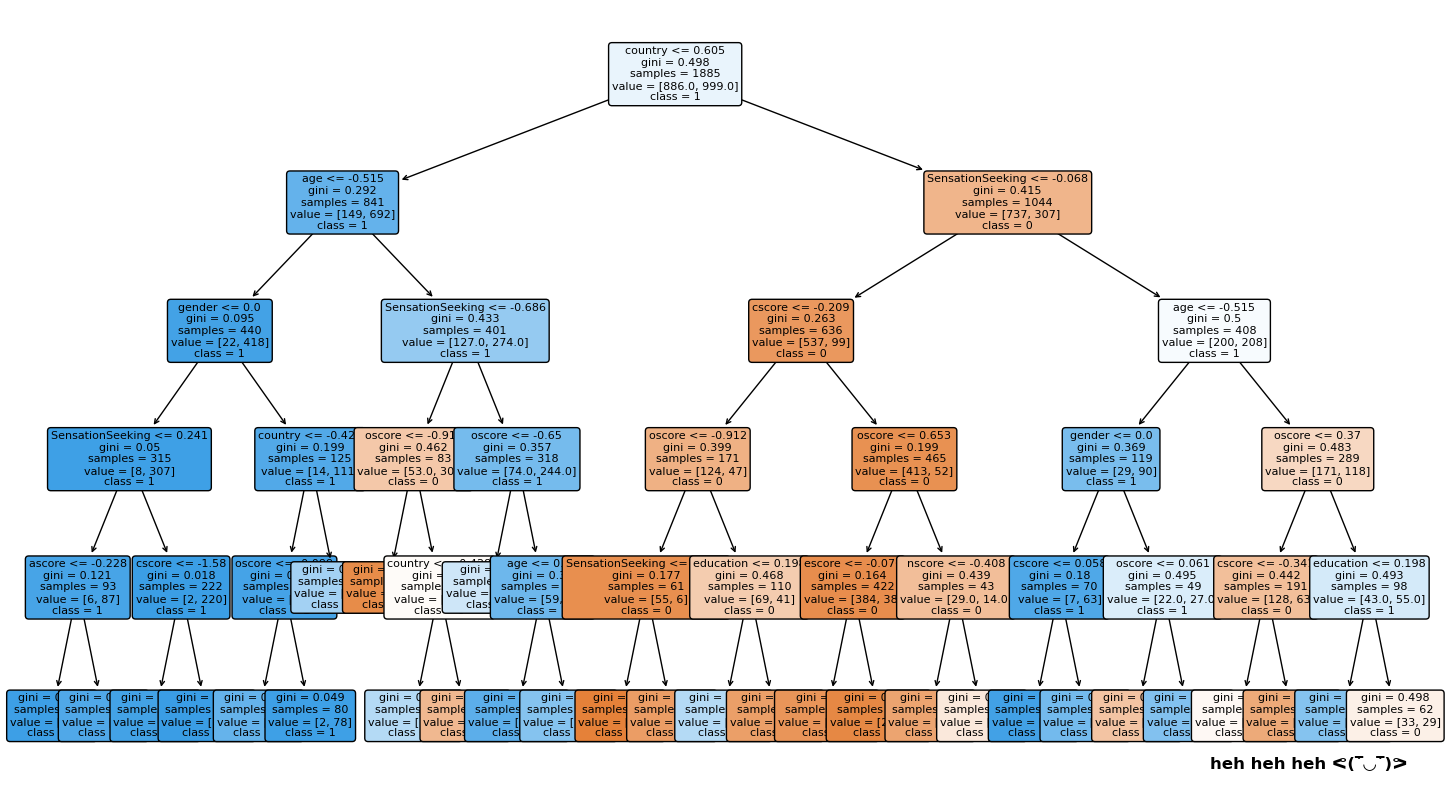

Saved tree diagram to secure_tree_plot.png


In [31]:
plt.figure(figsize=(18, 10))

tree.plot_tree(
    clf,
    feature_names=X.columns.tolist(),
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    fontsize=8
)

# Add text in bottom-right corner
plt.text(
    0.99, 0.01, "heh heh heh ᕙ(‾̀◡‾́)ᕗ",
    transform=plt.gca().transAxes,
    ha="right",
    va="bottom",
    fontsize=12,
    color="black",
    fontweight="bold"
)

# Save to file
plt.savefig("secure_tree_plot.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

print("Saved tree diagram to secure_tree_plot.png")

### Decision Path for a Single Input (Secure Evaluation)

This shows the sequence of comparisons and branches taken during the 
secure evaluation of one sample. Helpful for demonstrating how SMPC-style 
inference works.


In [36]:
def print_decision_path(root, x):
    node = root
    depth = 0
    while not node.is_leaf:
        f = node.feature_index
        t = node.threshold
        val = x[f]
        bit = secure_compare(val, t)
        
        print(f"[Depth {depth}] Compare: x[{f}]={val:.4f} <= {t:.4f} ? -> bit={bit}")
        
        node = node.left if bit == 1 else node.right
        depth += 1
        
    print(f"Reached leaf --> prediction={node.prediction}")

# Test on first instance
print_decision_path(root, X.iloc[0].tolist())

[Depth 0] Compare: x[3]=0.9608 <= 0.6050 ? -> bit=0
[Depth 1] Compare: x[11]=-1.1808 <= -0.0679 ? -> bit=1
[Depth 2] Compare: x[9]=-0.0066 <= -0.2094 ? -> bit=0
[Depth 3] Compare: x[7]=-0.5833 <= 0.6533 ? -> bit=1
[Depth 4] Compare: x[6]=-0.5755 <= -0.0758 ? -> bit=1
Reached leaf --> prediction=0
